Instagram is an American photo and video sharing social networking service founded in 2010 by
Kevin Systrom and Mike Krieger, and later acquired by American company Facebook Inc., now
known as Meta Platforms. The app allows users to share posts that can be shared publicly or
with pre-approved followers.

Instagram is very much used to influence people in a particular way for a specific issue - which
can impact the order in some ways. The following dataset is about such influencers. The fields
in the given dataset are as follows:

In [73]:
import pandas as pd

#### Loading the Dataset

In [74]:
df = pd.read_csv("Influencer.csv")
df

,Rank,Channel Info,Influence Score,Followers,Avg. Likes,Posts,60-Day Eng Rate,New Post Avg. Likes,Total Likes,Country Or Region
0,1,\ncristiano,92,485.2m,8.7m,3.4k,0.013,6.3m,29.1b,Spain
1,2,kyliejenner,91,370.7m,8.2m,7.0k,0.014,5.0m,57.4b,United States
2,3,\nleomessi,90,363.9m,6.7m,915,0.010,3.5m,6.1b,NaN
3,4,\nselenagomez,93,348.8m,6.1m,1.9k,0.005,1.7m,11.4b,United States
4,5,\ntherock,91,339.4m,1.8m,6.8k,0.003,932.0k,12.6b,United States
...,...,...,...,...,...,...,...,...,...,...
195,196,\nkhabib_nurmagomedov,63,33.6m,680.6k,4.6k,0.009,305.7k,3.1b,Russia
196,197,\ndanbilzerian,84,33.6m,2.2m,1.4k,0.064,2.1m,3.0b,Canada
197,198,\nraisa6690,80,33.6m,227.8k,4.2k,0.003,103.2k,955.9m,Indonesia
198,199,\nluansantana,79,33.5m,193.3k,865,0.003,82.6k,167.2m,Brazil


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Rank                 200 non-null    int64  
 1   Channel Info         200 non-null    str    
 2   Influence Score      200 non-null    int64  
 3   Followers            200 non-null    str    
 4   Avg. Likes           200 non-null    str    
 5   Posts                200 non-null    str    
 6   60-Day Eng Rate      200 non-null    float64
 7   New Post Avg. Likes  200 non-null    str    
 8   Total Likes          200 non-null    str    
 9   Country Or Region    137 non-null    str    
dtypes: float64(1), int64(2), str(7)
memory usage: 15.8 KB


In [76]:
df.describe()

,Rank,Influence Score,60-Day Eng Rate
count,200.000000,200.000000,200.000000
mean,100.500000,81.850000,0.019160
std,57.879185,8.875323,0.032577
min,1.000000,22.000000,0.000000
25%,50.750000,80.000000,0.004000
50%,100.500000,84.000000,0.009500
75%,150.250000,86.000000,0.017250
max,200.000000,93.000000,0.250000


In [77]:
df.isnull().sum()

Rank                    0
Channel Info            0
Influence Score         0
Followers               0
Avg. Likes              0
Posts                   0
60-Day Eng Rate         0
New Post Avg. Likes     0
Total Likes             0
Country Or Region      63
dtype: int64

#### Dropping NA rows

In [78]:
df.dropna(inplace=True)

In [79]:
df.head(4)

,Rank,Channel Info,Influence Score,Followers,Avg. Likes,Posts,60-Day Eng Rate,New Post Avg. Likes,Total Likes,Country Or Region
0,1,\ncristiano,92,485.2m,8.7m,3.4k,0.013,6.3m,29.1b,Spain
1,2,kyliejenner,91,370.7m,8.2m,7.0k,0.014,5.0m,57.4b,United States
3,4,\nselenagomez,93,348.8m,6.1m,1.9k,0.005,1.7m,11.4b,United States
4,5,\ntherock,91,339.4m,1.8m,6.8k,0.003,932.0k,12.6b,United States


#### Created a Funtion that converts Alphanumeric to Numeric

In [80]:
def convert_values(value):
    if isinstance(value, str):
        value = value.strip().lower()
        if 'b' in value:   # billions
            return float(value.replace('b','')) * 1_000_000_000
        elif 'm' in value: # millions
            return float(value.replace('m','')) * 1_000_000
        elif 'k' in value: # thousands
            return float(value.replace('k','')) * 1_000
    return float(value)

In [81]:
df['New Post Avg. Likes'] = df['New Post Avg. Likes'].apply(convert_values).astype(int)
df['Followers']=df['Followers'].apply(convert_values).astype(int)
df['Total Likes']=df['Total Likes'].apply(convert_values).astype(int)
df['Avg. Likes']=df['Avg. Likes'].apply(convert_values).astype(int)
df['Posts']=df['Posts'].apply(convert_values).astype(int)

In [82]:
df.head()

,Rank,Channel Info,Influence Score,Followers,Avg. Likes,Posts,60-Day Eng Rate,New Post Avg. Likes,Total Likes,Country Or Region
0,1,\ncristiano,92,485200000,8700000,3400,0.013,6300000,29100000000,Spain
1,2,kyliejenner,91,370700000,8199999,7000,0.014,5000000,57400000000,United States
3,4,\nselenagomez,93,348800000,6100000,1900,0.005,1700000,11400000000,United States
4,5,\ntherock,91,339400000,1800000,6800,0.003,932000,12600000000,United States
5,6,\narianagrande,92,333000000,3700000,5000,0.009,3100000,18500000000,United States


#### Checking Data Types

In [83]:
df.info()

<class 'pandas.DataFrame'>
Index: 137 entries, 0 to 199
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Rank                 137 non-null    int64  
 1   Channel Info         137 non-null    str    
 2   Influence Score      137 non-null    int64  
 3   Followers            137 non-null    int64  
 4   Avg. Likes           137 non-null    int64  
 5   Posts                137 non-null    int64  
 6   60-Day Eng Rate      137 non-null    float64
 7   New Post Avg. Likes  137 non-null    int64  
 8   Total Likes          137 non-null    int64  
 9   Country Or Region    137 non-null    str    
dtypes: float64(1), int64(7), str(2)
memory usage: 11.8 KB


In [84]:
df['Channel Info'] = df['Channel Info'].str.replace('\n', '', regex=False)

In [85]:
df.head(5)

,Rank,Channel Info,Influence Score,Followers,Avg. Likes,Posts,60-Day Eng Rate,New Post Avg. Likes,Total Likes,Country Or Region
0,1,cristiano,92,485200000,8700000,3400,0.013,6300000,29100000000,Spain
1,2,kyliejenner,91,370700000,8199999,7000,0.014,5000000,57400000000,United States
3,4,selenagomez,93,348800000,6100000,1900,0.005,1700000,11400000000,United States
4,5,therock,91,339400000,1800000,6800,0.003,932000,12600000000,United States
5,6,arianagrande,92,333000000,3700000,5000,0.009,3100000,18500000000,United States


### 1. Are there any correlated features in the given dataset? If yes, state the correlation coefficient of the pair of features which are highly correlated.

In [86]:
numeric_df = df.drop(['Channel Info','Country Or Region'],axis=1)

In [87]:
numeric_df.corr()

,Rank,Influence Score,Followers,Avg. Likes,Posts,60-Day Eng Rate,New Post Avg. Likes,Total Likes
Rank,1.000000,-0.482216,-0.703721,-0.454651,-0.030802,0.000530,-0.402517,-0.467106
Influence Score,-0.482216,1.000000,0.442241,0.208166,0.174080,-0.114907,0.162473,0.295035
Followers,-0.703721,0.442241,1.000000,0.607207,0.057784,-0.098256,0.465740,0.693586
Avg. Likes,-0.454651,0.208166,0.607207,1.000000,-0.321193,0.542864,0.846725,0.669669
Posts,-0.030802,0.174080,0.057784,-0.321193,1.000000,-0.370828,-0.227671,0.194077
60-Day Eng Rate,0.000530,-0.114907,-0.098256,0.542864,-0.370828,1.000000,0.702672,0.108434
New Post Avg. Likes,-0.402517,0.162473,0.465740,0.846725,-0.227671,0.702672,1.000000,0.613992
Total Likes,-0.467106,0.295035,0.693586,0.669669,0.194077,0.108434,0.613992,1.000000


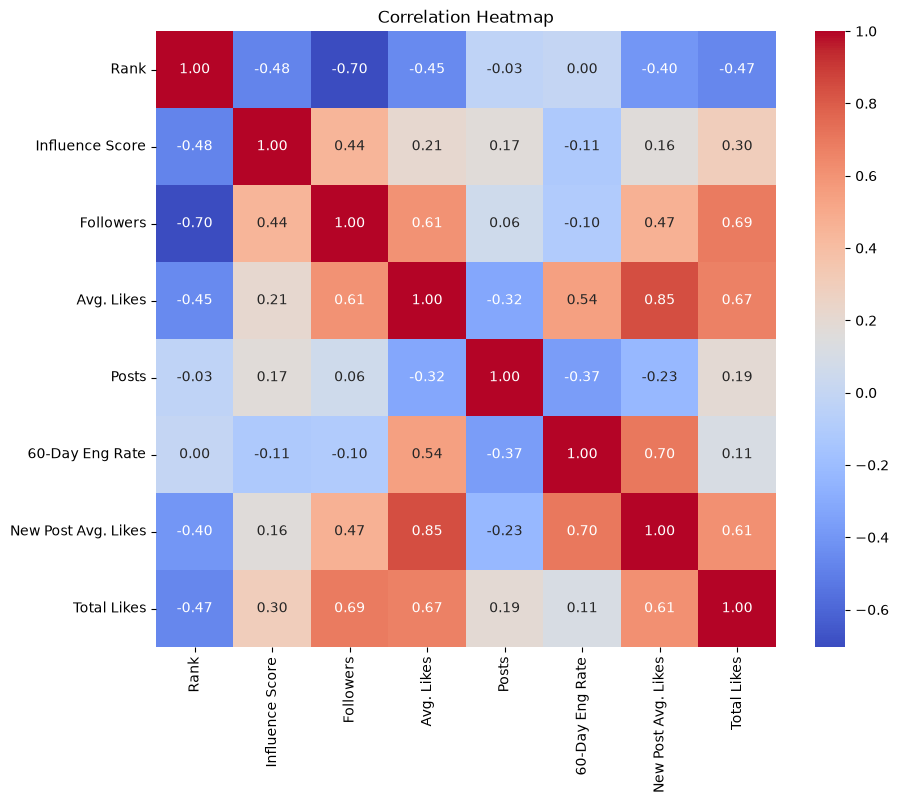

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Insights from Correlation Heatmap
- **Followers ↔ Total Likes** show a very strong positive correlation → influencers with more followers tend to accumulate more total likes.  
- **Avg. Likes ↔ New Post Avg. Likes** also have a high correlation (≈0.85) → consistent engagement across posts.  
- **Rank ↔ Followers** is negatively correlated (≈-0.70) → lower rank values correspond to higher follower counts.  
- **Posts ↔ Engagement Rate** are weakly related → posting more does not necessarily increase engagement.  
- Influence Score aligns moderately with Followers and Likes, but not strongly with Posts.  


### 2. What is the frequency distribution of the following features?
- Influence Score
- Followers
- Posts

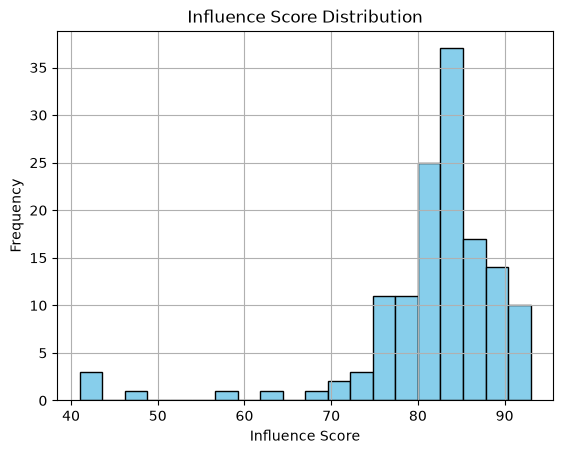

In [89]:
# Influence Score Distributions
df['Influence Score'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title("Influence Score Distribution")
plt.xlabel("Influence Score")
plt.ylabel("Frequency")
plt.show()

### Insights from Influence Score Distribution
- The distribution is **right-skewed**, with most influencers scoring between 75 and 90.  
- A clear peak appears around **85**, showing that many influencers cluster at high influence levels.  
- Very few influencers fall below 70, indicating that the dataset is dominated by accounts with strong influence.  
- This suggests the sample is **biased toward top-tier influencers**, rather than a balanced mix of small and large accounts.  


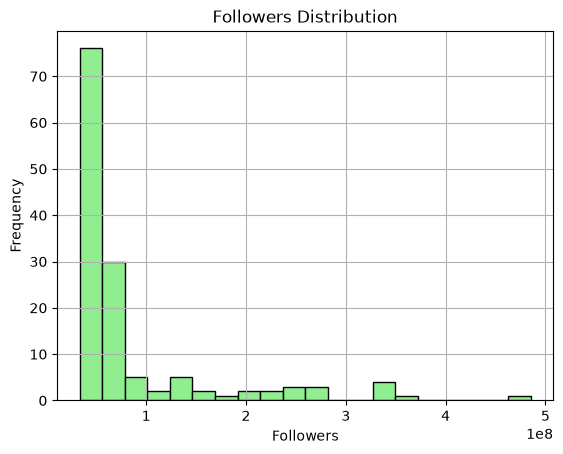

In [90]:
# Followers Distribution
df['Followers'].hist(bins=20, color='lightgreen', edgecolor='black')
plt.title("Followers Distribution")
plt.xlabel("Followers")
plt.ylabel("Frequency")
plt.show()

### Insights from Followers Distribution
- The distribution is **heavily right-skewed**: most influencers have fewer than 100 million followers.  
- A small number of **mega-influencers** dominate the upper range, creating long tails in the data.  
- The first bin (0–100M) has the highest frequency, showing that the majority of accounts fall into this lower follower bracket.  
- This highlights a strong **imbalance in reach** — while a few accounts command hundreds of millions of followers, most operate at a much smaller scale.  

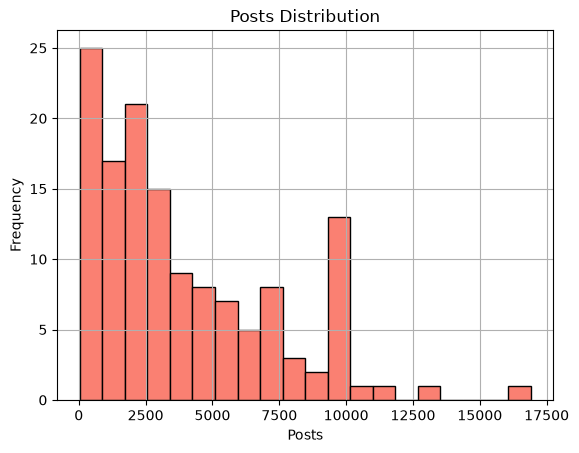

In [91]:
# Posts Distribution
df['Posts'].hist(bins=20, color='salmon', edgecolor='black')
plt.title("Posts Distribution")
plt.xlabel("Posts")
plt.ylabel("Frequency")
plt.show()

### Insights from Posts Distribution
- The majority of influencers have **fewer than 2,500 posts**, showing that most accounts maintain a moderate posting activity.  
- A gradual decline in frequency occurs as post counts increase, with only a handful of influencers exceeding 7,500 or 10,000 posts.  
- Small peaks around 7,500 and 10,000 posts suggest a few highly active accounts that stand out from the rest.  
- Very few influencers surpass 12,500 posts, highlighting that **extreme posting activity is rare** in this dataset.  


### 3. Which country houses the highest number of Instagram Influencers? Please show the count of Instagram influencers in different countries using barchart.

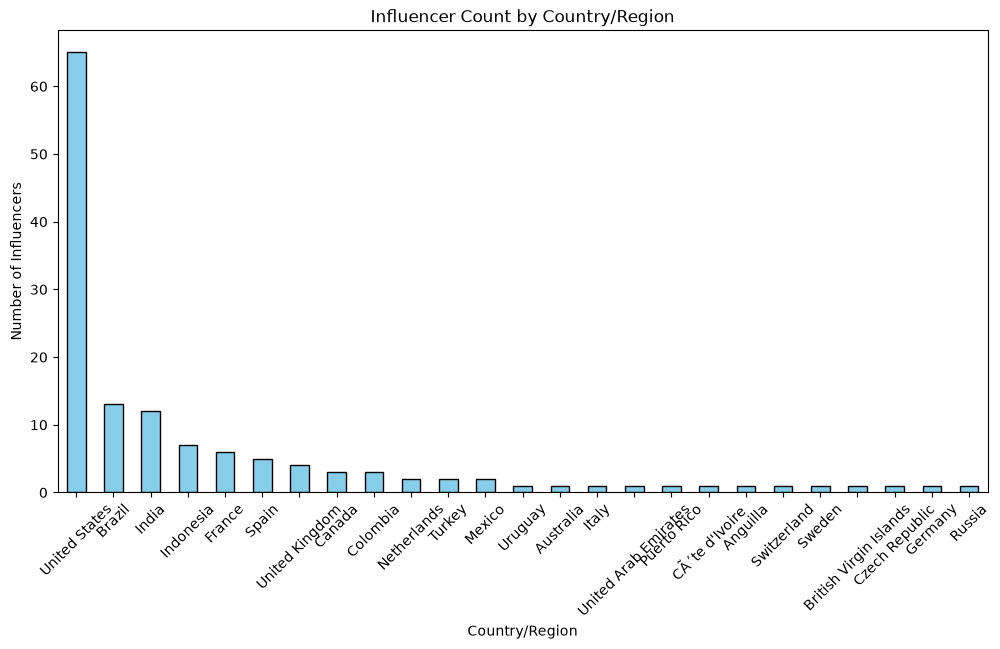

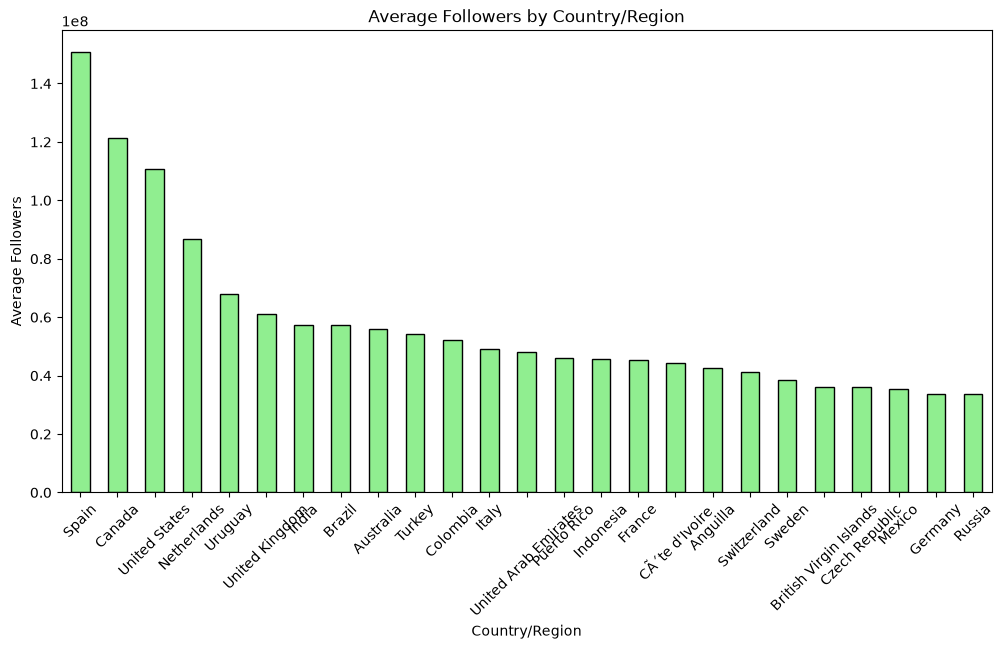

In [92]:
# Count of influencers by country
df['Country Or Region'].value_counts().plot(kind='bar', figsize=(12,6), color='skyblue', edgecolor='black')
plt.title("Influencer Count by Country/Region")
plt.xlabel("Country/Region")
plt.ylabel("Number of Influencers")
plt.xticks(rotation=45)
plt.show()

# Average followers per country
df.groupby('Country Or Region')['Followers'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(12,6), color='lightgreen', edgecolor='black')
plt.title("Average Followers by Country/Region")
plt.xlabel("Country/Region")
plt.ylabel("Average Followers")
plt.xticks(rotation=45)
plt.show()

### Insights from Country/Region Analysis
- The **United States dominates** the dataset, with more than 60 influencers — far ahead of other countries.  
- Brazil and India follow, but with much smaller counts (~12–13 influencers each), showing a steep drop after the U.S. lead.  
- When looking at **average followers**, Spain ranks highest despite having fewer influencers — driven largely by Cristiano Ronaldo’s massive following.  
- Canada and the United States also show high averages, suggesting that influencers from these regions tend to command larger audiences.  
- This highlights a **global imbalance**: a few countries (U.S., Spain, Canada) concentrate both the number of influencers and their reach, while most other regions have smaller representation and moderate averages.  


### 4. Who are the top 10 influencers in the given dataset based on the following features
- Followers
- Average likes
- Total Likes

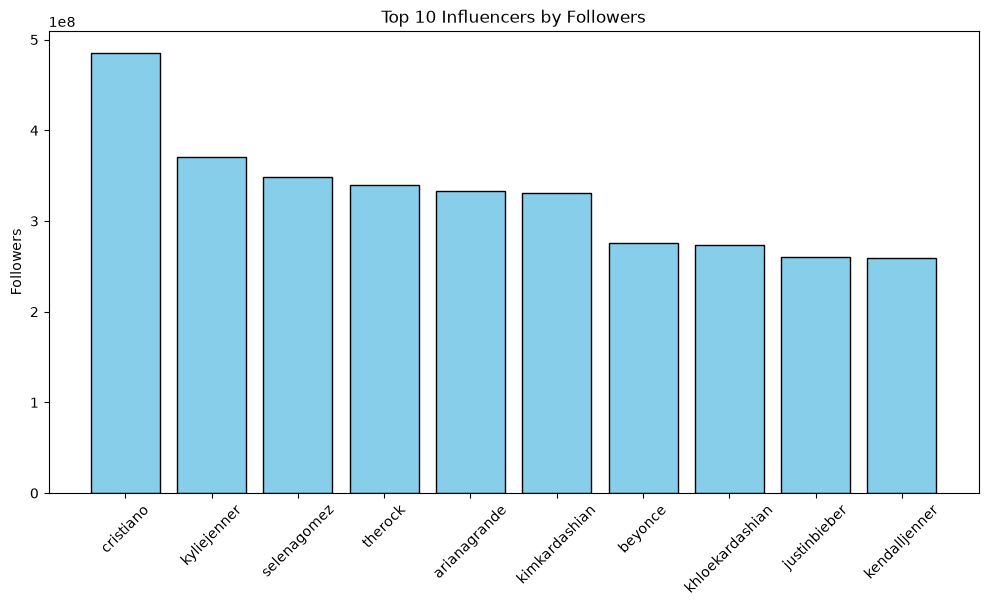

In [93]:
# Top 10 by Followers
top_followers = df.nlargest(10, 'Followers')
plt.figure(figsize=(12,6))
plt.bar(top_followers['Channel Info'], top_followers['Followers'], color='skyblue', edgecolor='black')
plt.title("Top 10 Influencers by Followers")
plt.xticks(rotation=45)
plt.ylabel("Followers")
plt.show()

### Insights from Top 10 Influencers by Followers
- **Cristiano Ronaldo** leads with the highest follower count, cementing his position as the most-followed influencer globally.  
- **Kylie Jenner** and **Selena Gomez** follow closely, showing the dominance of celebrity figures in social media reach.  
- The list is heavily populated by U.S.-based celebrities (Kylie Jenner, Selena Gomez, The Rock, Ariana Grande, Kim Kardashian, Beyoncé, Khloé Kardashian, Justin Bieber, Kendall Jenner).  
- This highlights that **celebrity status strongly correlates with follower dominance**, with sports and entertainment personalities driving the largest audiences.  
- The distribution shows a steep drop after the top few, reinforcing the **power-law nature of social media influence** — a handful of accounts command massive reach compared to the rest.  


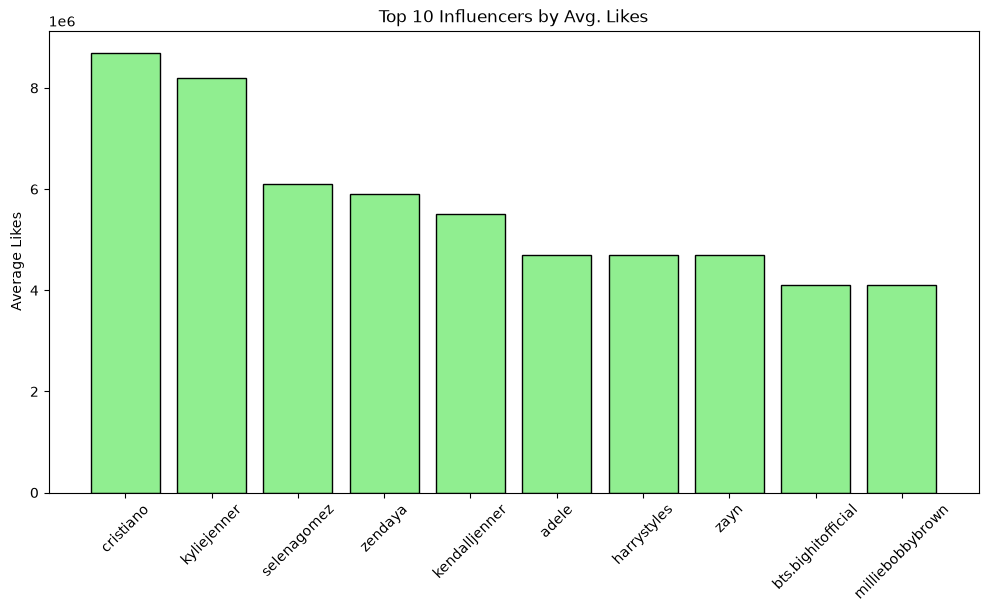

In [94]:
# Top 10 by Avg. Likes
top_avg_likes = df.nlargest(10, 'Avg. Likes')
plt.figure(figsize=(12,6))
plt.bar(top_avg_likes['Channel Info'], top_avg_likes['Avg. Likes'], color='lightgreen', edgecolor='black')
plt.title("Top 10 Influencers by Avg. Likes")
plt.xticks(rotation=45)
plt.ylabel("Average Likes")
plt.show()

### Insights from Top 10 Influencers by Avg. Likes
- **Cristiano Ronaldo** leads not only in followers but also in average likes, showing strong engagement per post.  
- **Kylie Jenner** and **Selena Gomez** follow closely, reinforcing their ability to consistently generate high interaction.  
- The presence of **Zendaya, Adele, Harry Styles, Zayn, BTS, and Millie Bobby Brown** highlights that strong engagement is not limited to follower count — newer or niche audiences can still drive high average likes.  
- This ranking emphasizes that **engagement quality matters as much as audience size**: some influencers with fewer followers achieve comparable or even higher average likes than mega‑influencers.  


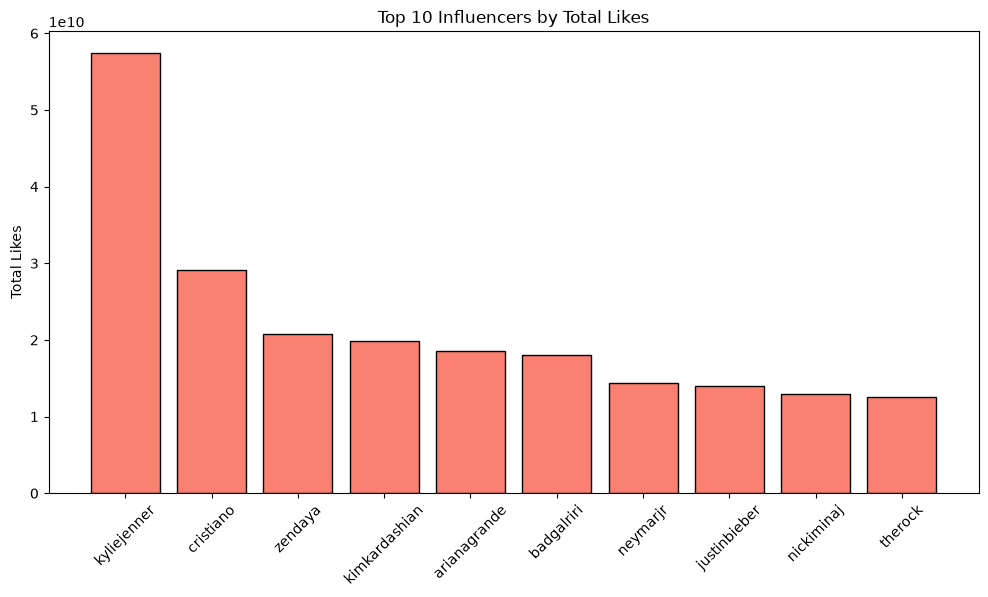

In [95]:
# Top 10 by Total Likes
top_total_likes = df.nlargest(10, 'Total Likes')
plt.figure(figsize=(12,6))
plt.bar(top_total_likes['Channel Info'], top_total_likes['Total Likes'], color='salmon', edgecolor='black')
plt.title("Top 10 Influencers by Total Likes")
plt.xticks(rotation=45)
plt.ylabel("Total Likes")
plt.show()

### Insights from Top 10 Influencers by Total Likes
- **Kylie Jenner** leads with the highest total likes, reflecting both her massive follower base and consistently high engagement.  
- **Cristiano Ronaldo** follows closely, showing that his global reach translates into enormous cumulative interaction.  
- Other celebrities such as **Zendaya, Kim Kardashian, Ariana Grande, Rihanna, Neymar Jr., Justin Bieber, Nicki Minaj, and The Rock** also appear in the top 10, highlighting the dominance of entertainment and sports figures.  
- The ranking reveals that **total likes capture long-term impact**: influencers with sustained posting activity and loyal audiences accumulate billions of likes over time.  
- This metric emphasizes the **compounding effect of both reach and consistency** — those who post regularly and maintain engagement rise to the top in overall influence.  


### 5. Describe the relationship between the following pairs of features using a suitable graph
- Followers and Total Likes
- Followers and Influence Score
- Posts and Average likes
- Posts and Influence Score

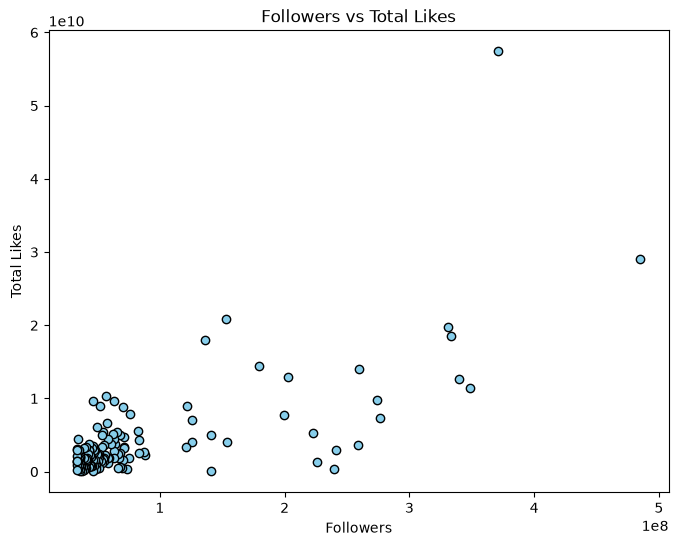

In [96]:
# Followers vs Total Likes
plt.figure(figsize=(8,6))
plt.scatter(df['Followers'], df['Total Likes'], color='skyblue', edgecolor='black')
plt.title("Followers vs Total Likes")
plt.xlabel("Followers")
plt.ylabel("Total Likes")
plt.show()

### Insights from Followers vs Total Likes
- The scatter plot shows a **strong positive relationship**: influencers with more followers generally accumulate higher total likes.  
- Most data points cluster at the lower end of both axes, representing influencers with modest reach and engagement.  
- A few **outliers** (mega-influencers) stand far apart, with extremely high follower counts and billions of total likes, driving the overall trend.  
- This pattern reinforces the idea of a **power-law distribution** in social media: a small number of accounts dominate both reach and cumulative engagement.  


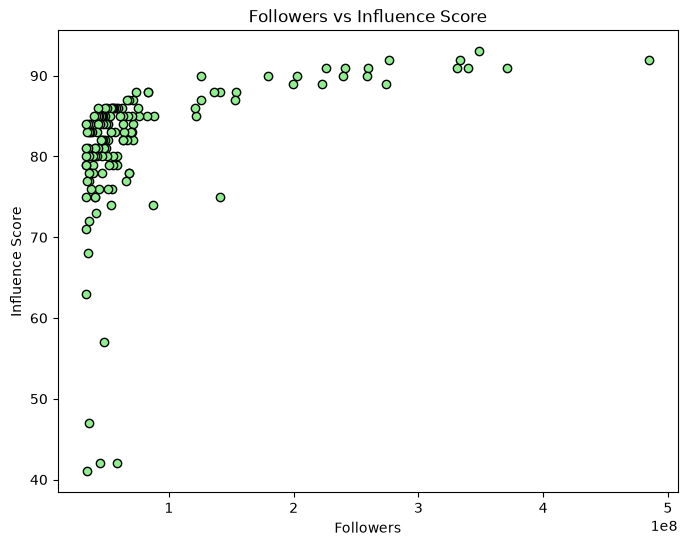

In [97]:
# Followers vs Influence Score
plt.figure(figsize=(8,6))
plt.scatter(df['Followers'], df['Influence Score'], color='lightgreen', edgecolor='black')
plt.title("Followers vs Influence Score")
plt.xlabel("Followers")
plt.ylabel("Influence Score")
plt.show()

### Insights from Followers vs Influence Score
- The plot shows a **positive relationship**: as follower counts increase, influence scores tend to be higher.  
- Most influencers cluster between **70 and 90 influence score**, regardless of follower size, indicating that influence is not purely follower-driven.  
- A few mega-influencers with extremely high follower counts also achieve top influence scores, reinforcing their dominance.  
- The spread suggests that while followers contribute to influence, **engagement quality and consistency** also play a role in determining the score.  


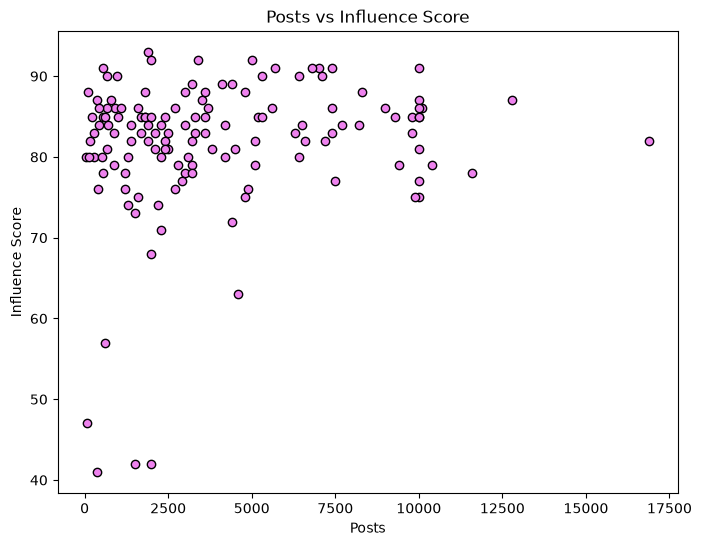

In [98]:
plt.figure(figsize=(8,6))
plt.scatter(df['Posts'], df['Influence Score'], color='violet', edgecolor='black')
plt.title("Posts vs Influence Score")
plt.xlabel("Posts")
plt.ylabel("Influence Score")
plt.show()

### Insights from Posts vs Influence Score
- The scatter plot shows **no strong correlation** between the number of posts and influence score.  
- Most influencers cluster between **0–5000 posts** with influence scores in the **70–90 range**, suggesting that posting volume alone does not drive influence.  
- A few outliers with very high post counts actually show **lower influence scores**, reinforcing that quality and audience engagement matter more than sheer quantity.  
- This indicates that **consistent, meaningful engagement** is more critical to influence than simply producing a large volume of content.  
